Nom : KARBOUN Ahmed Master : GLCC

Analyse KNN (Minkowski p=1)
----------------------------------------
K     | Note       | Statut
----------------------------------------
1     | 9.00       | Échec
2     | 8.50       | Échec
3     | 8.00       | Échec
4     | 8.75       | Échec
5     | 10.50      | Réussite
6     | 10.42      | Réussite
7     | 10.36      | Réussite
8     | 10.19      | Réussite
9     | 10.28      | Réussite
10    | 10.05      | Réussite


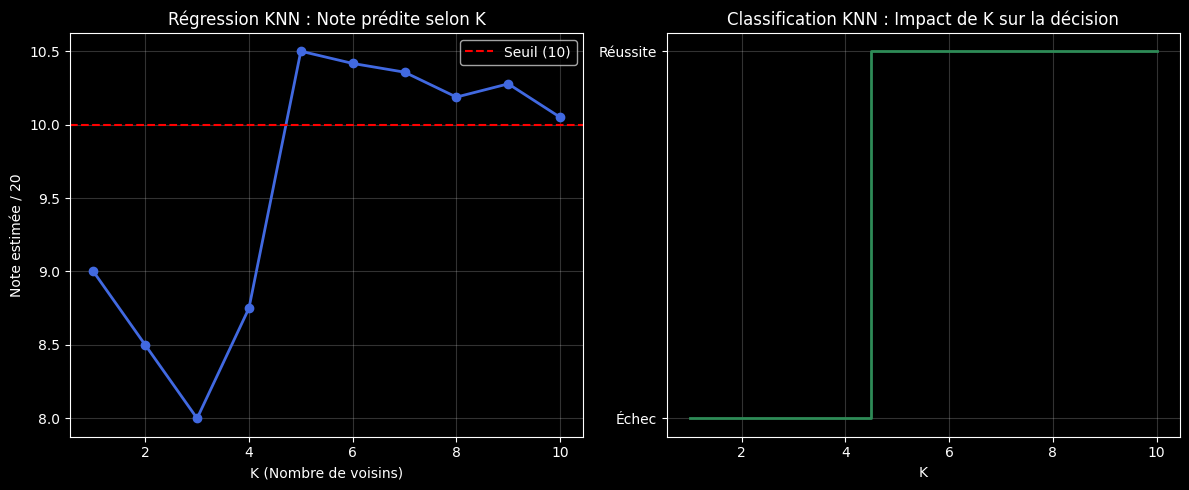

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. PRÉPARATION DU DATASET ENRICHI
# Logic: X contient les variables explicatives (features).
# Chaque colonne est normalisée plus tard pour éviter que les variables à
# forte amplitude (ex: Score Précédent) n'étouffent les autres.
# =============================================================================
X = np.array([
    [2,5,8,20,0,6], [4,6,6,40,2,5], [6,7,5,60,3,4], [8,7,4,80,4,3], [10,8,3,90,5,2],
    [3,4,9,30,0,7], [7,6,5,70,3,4], [5,5,6,50,2,5], [9,8,4,85,4,3], [1,3,9,15,1,8],
    [6,6,5,65,3,4], [7,7,4,75,3,3], [8,8,3,88,4,2], [2,4,8,25,1,6], [3,5,7,35,2,6],
    [4,7,6,45,2,5], [5,6,6,55,3,4], [6,8,5,68,3,3], [7,5,5,72,4,3], [9,7,4,82,4,2],
    [10,9,3,95,5,1], [2,3,9,10,1,9], [3,4,8,28,2,7], [6,5,6,60,3,4], [7,6,5,70,3,3],
    [8,7,4,78,4,2], [9,8,3,88,5,2], [1,2,9,12,0,9], [2,6,7,22,1,7], [3,7,6,32,1,6],
    [4,8,5,42,2,5], [5,9,4,52,2,4], [6,3,8,62,3,5], [7,4,7,72,3,4], [8,5,6,82,4,3],
    [9,6,5,92,5,2], [10,7,4,98,5,1], [2,5,7,18,0,8], [3,6,6,28,1,7], [4,7,5,38,2,6],
    [5,8,4,48,2,5], [6,9,3,58,3,4], [7,3,9,68,3,6], [8,4,8,78,4,5], [9,5,7,88,4,4],
    [10,6,6,96,5,3], [1,7,8,14,1,8]
])

notes = np.array([
    10, 13, 15, 17, 18.5, 11, 16, 12, 17, 9, 14, 15, 18, 10, 11,
    13, 14, 15, 16, 17, 19, 8, 9, 14, 15, 16, 17, 7, 8, 9.5, 10.5,
    11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18, 19, 20, 6, 7.5,
    8.5, 9, 10, 11, 12, 13
])

# =============================================================================
# 2. NORMALISATION (Z-SCORE)
# Logic: Crucial pour le KNN. On centre les données (moyenne = 0) et on les
# réduit (écart-type = 1). Cela garantit l'équité entre les caractéristiques.
# =============================================================================
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean) / X_std

# =============================================================================
# 3. INNOVATION : DISTANCE DE MINKOWSKI
# Math Logic: D(x, y) = ( sum( |xi - yi|^p ) )^(1/p)
# p=1: Manhattan | p=2: Euclidienne. Utiliser p permet de moduler la sensibilité
# aux écarts extrêmes.
# =============================================================================
def distance_minkowski(x1, x2, p=2):
    return np.sum(np.abs(x1 - x2)**p)**(1/p)

# =============================================================================
# 4. MOTEUR DE PRÉDICTION KNN
# Logic: Identifie les K profils les plus proches dans l'espace multidimensionnel.
# =============================================================================
def knn_engine(X_train, y_train, x_test, K, p_metric=2):
    distances = []
    for i in range(len(X_train)):
        # Calcul de la proximité mathématique entre le test et chaque échantillon
        d = distance_minkowski(x_test, X_train[i], p=p_metric)
        distances.append((d, y_train[i]))

    # Tri par ordre croissant de distance (les voisins les plus "similaires")
    distances.sort(key=lambda x: x[0])
    k_voisins = distances[:K]

    # Extraction des labels (notes) des voisins sélectionnés
    valeurs_voisins = [v[1] for v in k_voisins]

    # Retourne la moyenne pondérée (ici simple) pour la régression
    return np.mean(valeurs_voisins)

# =============================================================================
# 5. SIMULATION ET ANALYSE DES RÉSULTATS
# =============================================================================
# Profil d'un étudiant "à risque" : peu d'étude (2h), bcp d'absences (9), fatigue (8)
etudiant_test = np.array([[2, 3, 9, 15, 0, 8]])
x_test_norm = (etudiant_test - X_mean) / X_std
x_test_norm = x_test_norm.flatten()

SEUIL_REUSSITE = 10 # On remonte le seuil à 10 pour une analyse plus stricte
P_VAL = 1 # On utilise ici Manhattan (p=1) pour la robustesse aux outliers

liste_k = range(1, 11)
pred_notes = []
pred_classes = []

print(f"Analyse KNN (Minkowski p={P_VAL})")
print("-" * 40)
print(f"{'K':<5} | {'Note':<10} | {'Statut'}")
print("-" * 40)

for K in liste_k:
    note_finale = knn_engine(X_norm, notes, x_test_norm, K, p_metric=P_VAL)

    # Classification basée sur la note prédite
    classe = 1 if note_finale >= SEUIL_REUSSITE else 0
    statut = "Réussite" if classe == 1 else "Échec"

    pred_notes.append(note_finale)
    pred_classes.append(classe)

    print(f"{K:<5} | {note_finale:<10.2f} | {statut}")

# =============================================================================
# 6. VISUALISATION SCIENTIFIQUE
# =============================================================================
plt.figure(figsize=(12, 5))

# Graphique 1 : Régression (Évolution de la note)
plt.subplot(1, 2, 1)
plt.plot(liste_k, pred_notes, marker='o', color='royalblue', linewidth=2)
plt.axhline(y=SEUIL_REUSSITE, color='red', linestyle='--', label=f'Seuil ({SEUIL_REUSSITE})')
plt.title("Régression KNN : Note prédite selon K")
plt.xlabel("K (Nombre de voisins)")
plt.ylabel("Note estimée / 20")
plt.legend()
plt.grid(True, alpha=0.2)

# Graphique 2 : Classification (Saut discret)
plt.subplot(1, 2, 2)
plt.step(liste_k, pred_classes, where='mid', color='seagreen', linewidth=2)
plt.yticks([0, 1], ["Échec", "Réussite"])
plt.title("Classification KNN : Impact de K sur la décision")
plt.xlabel("K")
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()